In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [8]:
result_dir = "/home/swim/bo-ptycho/results/Si8V2_2/260815"
train_x = np.load(os.path.join(result_dir, 'train_x.npy')).T
train_y = np.load(os.path.join(result_dir, 'train_y.npy')).T

xparams = [
    'defocus [A]',
    'layers',
    'thickness [A]'
]

print(train_x.shape)

(3, 564)


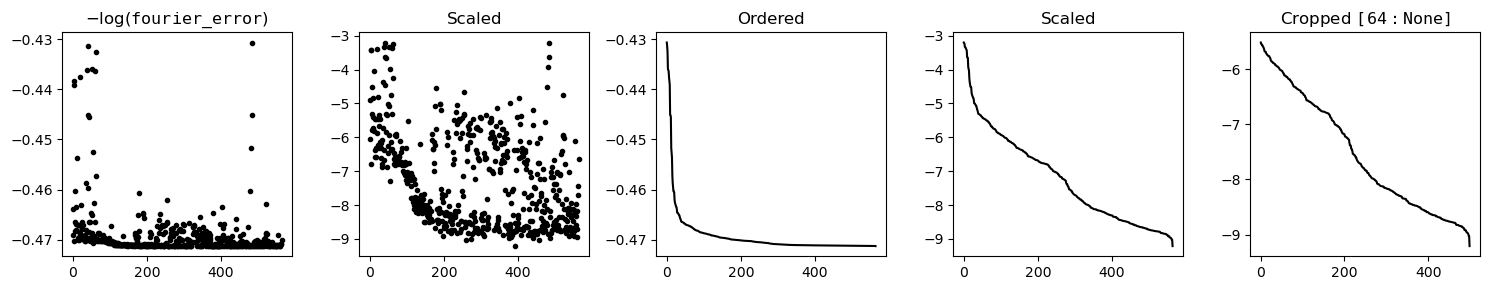

In [9]:
EPSILON = 1e-4
START   = 64
END     = None

sort_index = np.argsort(train_y)
x = train_x[:,sort_index]
y = train_y[sort_index]
y_scaled = np.log(-y + y[-1] + EPSILON)
train_y_scaled = np.log(-train_y + y[-1] + EPSILON)

fig, ax = plt.subplots(1, 5, figsize=(15,3))
ax[0].plot(-train_y, 'k.')
ax[0].set_title("$-\\log(\\mathtt{fourier\\_error})$")
ax[1].plot(train_y_scaled, 'k.')
ax[1].set_title("Scaled")
ax[2].sharey(ax[0])
ax[2].plot(-y, 'k')
ax[2].set_title("Ordered")
ax[3].plot(y_scaled, 'k')
ax[3].set_title("Scaled")
ax[4].plot(y_scaled[START:END], 'k')
ax[4].set_title(f"Cropped $\\mathtt{{[{START}:{END}]}}$")
plt.tight_layout()
plt.show()

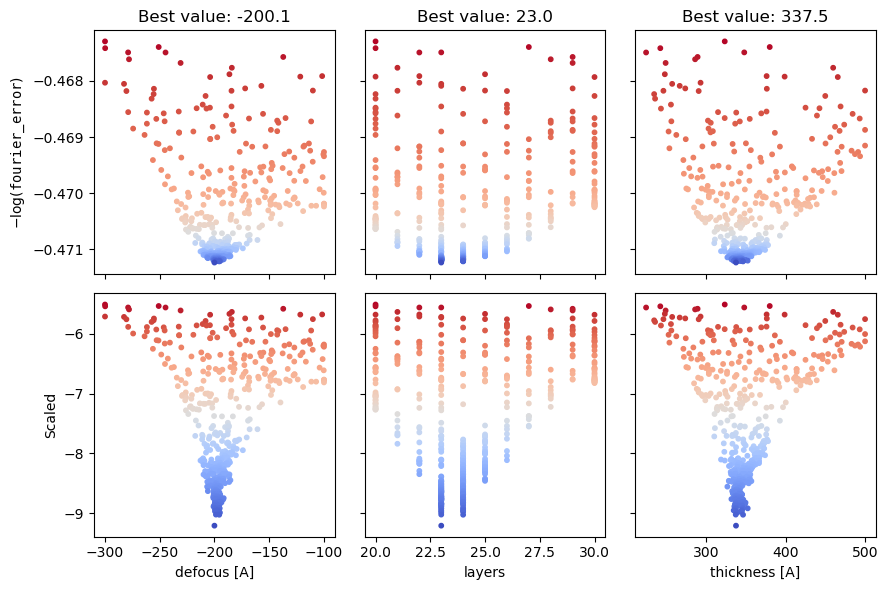

  Best BO trial : index 391
    defocus [A] :   -200.06
         layers :     23.00
  thickness [A] :    337.54
    log fourier :  -0.47124


In [10]:
fig, axs = plt.subplots(2, len(x), figsize=(3*len(x), 6), sharey='row', sharex='col')
for i, axi in enumerate(axs[0]):
    axi.scatter(x[i][START:END], -y[START:END], c=y_scaled[START:END], cmap='coolwarm', s=10)
    axi.set_title(f"Best value: {x[i,-1]:.1f}")

axs[0][0].set_ylabel('$- \\log (\\mathtt{fourier\\_error})$')

for i, axi in enumerate(axs[1]):
    axi.scatter(x[i][START:END], y_scaled[START:END], c=y_scaled[START:END], cmap='coolwarm', s=10)
    axi.set_xlabel(xparams[i])
axs[1][0].set_ylabel('Scaled')
plt.tight_layout()
plt.show()

print(f"  Best BO trial : index {train_y.argmax()}")
print("\n".join([f'{xparams[i]:>15} : {x[i, -1]:> 9.2f}' for i in range(len(xparams))]))
print(f"    log fourier : {-y[-1]:9.5f}")